In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#  add light grid to adll figs
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [3]:
def concat_results(base_dir, mode, suffix_present=True):
    df_list = []
    # 20, 30, 40, 50, 60, 70, 80, 90,
    suffix=""
    if (mode == "NProbe" and suffix_present):
        # print("nprobe")
        suffix="_with_oracle"

    for t in [0, 100]:
        df = pd.read_csv(f"{base_dir}/full_results_{mode}_t{t}{suffix}.csv")
        df["t"] = t
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

In [4]:
# theoretical recall @ 10 vs step
# on SIFT/MSTuring Static sets
# surge & gp-ann
# TODO: compute real imbalance information for all

In [5]:
# gp-ann to generate: (also computes real recall, runs in distributed setting)
# 1. python extract_first_batch.py
# 2. ./Partition - partitions on first batch
# 3. mv partitions ->partitions.local (only for shift?)
# 3. offset_partition.py partitions.local -> partitions (only for shift?)
# 2. ./DistributedInsertBenchSweep

# surge - to generate:
# 1. ./bin/msturing-cluster-analysis
# 2. ./bin/runbook_partitions_parallel
# 3. python compute_theoretical_recall_updated.py


# /dataset/surge/results/runbook_theoretical_runs/bigann-clustered/full_results_sweep_t0.csv
# /dataset/gp-ann-inserts/results/msturing100Mclustered_runbook_results_nprobe5.csv

In [6]:
# runbook phases for plotting
# step 0-128: insert
# step 128-256: delete
# step 256-384: insert
# step 384-512: delete
# step 512-640: insert
# step 640-768: delete
# step 768-896: insert
# step 896-1024: delete
# step 1024-1152: insert
# step 1152-1280: delete

# shift runbook phases:
# step 0-208: insert
# step 208-245: delete
# step 235-338: insert
# step 338-364: delete
# step 365-468: insert
# step 468-494: delete
# step 495-590: insert
# step 591-616: delete

In [7]:
no_rebuilds_color = "firebrick"
no_rebuilds_label = "no maintenance"

rebuilds_color = "C0"
rebuilds_label = "with maintenance"

In [8]:
shard_cols = ["shard_0_active","shard_1_active","shard_2_active",
              "shard_3_active","shard_4_active","shard_5_active",
              "shard_6_active","shard_7_active","shard_8_active","shard_9_active"]


def gini(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) / (n * np.sum(arr))) - (n + 1) / n

In [9]:
# bigann_clustered_path = "/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10/full_results_RecallTarget.csv"
# bigann_clustered = pd.read_csv(bigann_clustered_path)
bigann_clustered_path = "/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10"
bigann_clustered_recalltarget = concat_results(bigann_clustered_path, "RecallTarget")
bigann_clustered_bf = concat_results(bigann_clustered_path, "BranchingFactor")
bigann_clustered_nprobe = concat_results(bigann_clustered_path, "NProbe")

# concatenate all bigann clustered results into one dataframe
bigann_clustered = pd.concat([bigann_clustered_recalltarget, bigann_clustered_bf, bigann_clustered_nprobe], axis=0)

gpann_bigann_clustered = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/gpann_partitions/bigann100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")
gpann_bigann_clustered["gini"] = gpann_bigann_clustered[shard_cols].apply(lambda row: gini(row.values), axis=1)

bigann_clustered_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10/full_real_imbalance_no_rebuilding_results.csv")
bigann_clustered_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10/full_real_imbalance_rebuilding_results.csv")

bigann_clustered_imbalance_t0 = []
for step, group in bigann_clustered_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_clustered_imbalance_t0.append(gini(group["count"]))

bigann_clustered_imbalance_t100 = []
for step, group in bigann_clustered_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_clustered_imbalance_t100.append(gini(group["count"]))

In [10]:
bigann_random_path = "/dataset/big-ann-benchmarks/data/bigann-random/cluster_history_bigann-100M-random_10000_10"
bigann_random_recalltarget = concat_results(bigann_random_path, "RecallTarget")
bigann_random_bf = concat_results(bigann_random_path, "BranchingFactor")
bigann_random_nprobe = concat_results(bigann_random_path, "NProbe")

bigann_random = pd.concat([bigann_random_recalltarget, bigann_random_bf, bigann_random_nprobe], axis=0)

gpann_bigann_random = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-random/gpann_partitions/bigann100Mrandom_runbook_results_nprobe_with_theo_sweep.csv")
gpann_bigann_random["gini"] = gpann_bigann_random[shard_cols].apply(lambda row: gini(row.values), axis=1)

bigann_random_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-random/cluster_history_bigann-100M-random_10000_10/full_real_imbalance_no_rebuilding_results.csv")
bigann_random_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-random/cluster_history_bigann-100M-random_10000_10/full_real_imbalance_rebuilding_results.csv")

bigann_random_imbalance_t0 = []
for step, group in bigann_random_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_random_imbalance_t0.append(gini(group["count"]))

bigann_random_imbalance_t100 = []
for step, group in bigann_random_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_random_imbalance_t100.append(gini(group["count"]))

In [11]:
bigann_shift_path = "/dataset/big-ann-benchmarks/data/bigann-shift/cluster_history_bigann-100M-shift_10000_10"
bigann_shift_recalltarget = concat_results(bigann_shift_path, "RecallTarget")
bigann_shift_bf = concat_results(bigann_shift_path, "BranchingFactor")
bigann_shift_nprobe = concat_results(bigann_shift_path, "NProbe", False)

bigann_shift = pd.concat([bigann_shift_recalltarget, bigann_shift_bf, bigann_shift_nprobe], axis=0)

gpann_bigann_shift = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-shift/gpann_partitions/bigann100Mshift_runbook_results_nprobe_with_theo_sweep.csv")
gpann_bigann_shift["gini"] = gpann_bigann_shift[shard_cols].apply(lambda row: gini(row.values), axis=1)


bigann_shift_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-shift/cluster_history_bigann-100M-shift_10000_10/full_real_imbalance_no_rebuilding_results.csv")
bigann_shift_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-shift/cluster_history_bigann-100M-shift_10000_10/full_real_imbalance_rebuilding_results.csv")

bigann_shift_imbalance_t0 = []
for step, group in bigann_shift_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_shift_imbalance_t0.append(gini(group["count"]))

bigann_shift_imbalance_t100 = []
for step, group in bigann_shift_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_shift_imbalance_t100.append(gini(group["count"]))

In [12]:
msturing_random_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-random/cluster_history_msturing-100M-random_10000_10"
msturing_random_recalltarget = concat_results(msturing_random_path, "RecallTarget")
msturing_random_bf = concat_results(msturing_random_path, "BranchingFactor")
msturing_random_nprobe = concat_results(msturing_random_path, "NProbe")

msturing_random = pd.concat([msturing_random_recalltarget, msturing_random_bf, msturing_random_nprobe], axis=0)

# but gpann reports real recall
gpann_msturing_random = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-random/gpann_partitions/msturing100Mrandom_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing_random["gini"] = gpann_msturing_random[shard_cols].apply(lambda row: gini(row.values), axis=1)

msturing_random_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-random/cluster_history_msturing-100M-random_10000_10/full_real_imbalance_no_rebuilding_results.csv")
msturing_random_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-random/cluster_history_msturing-100M-random_10000_10/full_real_imbalance_rebuilding_results.csv")

msturing_random_imbalance_t0 = []
for step, group in msturing_random_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_random_imbalance_t0.append(gini(group["count"]))

msturing_random_imbalance_t100 = []
for step, group in msturing_random_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_random_imbalance_t100.append(gini(group["count"]))

In [13]:
msturing_clustered_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10"
msturing_clustered_recalltarget = concat_results(msturing_clustered_path, "RecallTarget")
msturing_clustered_bf = concat_results(msturing_clustered_path, "BranchingFactor")
msturing_clustered_nprobe = concat_results(msturing_clustered_path, "NProbe")

msturing_clustered = pd.concat([msturing_clustered_recalltarget, msturing_clustered_bf, msturing_clustered_nprobe], axis=0)

msturing_clustered_distrib_t100 = pd.read_csv("/users/dkhimey/surge/msturing100clustered_sweep_with_theo_t100.csv")
msturing_clustered_distrib_t60 = pd.read_csv("/users/dkhimey/surge/msturing100clustered_sweep_with_theo_t60.csv")

gpann_msturing_clustered = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/gpann_partitions/msturing100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing_clustered["gini"] = gpann_msturing_clustered[shard_cols].apply(lambda row: gini(row.values), axis=1)


msturing_clustered_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10/full_real_imbalance_no_rebuilding_results.csv")
msturing_clustered_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10/full_real_imbalance_rebuilding_results.csv")

msturing_clustered_imbalance_t0 = []
for step, group in msturing_clustered_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_clustered_imbalance_t0.append(gini(group["count"]))

msturing_clustered_imbalance_t100 = []
for step, group in msturing_clustered_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_clustered_imbalance_t100.append(gini(group["count"]))

/tmp/ipykernel_501993/2661033225.py:9: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  msturing_clustered_distrib_t60 = pd.read_csv("/users/dkhimey/surge/msturing100clustered_sweep_with_theo_t60.csv")


In [14]:
msturing_shift_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10"
msturing_shift_weighted_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10_nodeweighted/"

msturing_shift_recalltarget = concat_results(msturing_shift_path, "RecallTarget")
msturing_shift_bf = concat_results(msturing_shift_path, "BranchingFactor")
msturing_shift_nprobe = concat_results(msturing_shift_path, "NProbe")

# msturing_shift_weighted_recalltarget = concat_results(msturing_shift_weighted_path, "RecallTarget")

msturing_shift = pd.concat([msturing_shift_recalltarget, msturing_shift_bf, msturing_shift_nprobe], axis=0)
# msturing_shift_weighted = pd.concat([msturing_shift_weighted_recalltarget], axis=0)

gpann_msturing_shift = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/gpann_partitions/msturing100Mshift_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing_shift["gini"] = gpann_msturing_shift[shard_cols].apply(lambda row: gini(row.values), axis=1)

msturing_shift_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10/full_real_imbalance_no_rebuilding_results.csv")
msturing_shift_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10/full_real_imbalance_rebuilding_results.csv")

msturing_shift_imbalance_t0 = []
for step, group in msturing_shift_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_shift_imbalance_t0.append(gini(group["count"]))

msturing_shift_imbalance_t100 = []
for step, group in msturing_shift_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_shift_imbalance_t100.append(gini(group["count"]))

# SIFT ---------------

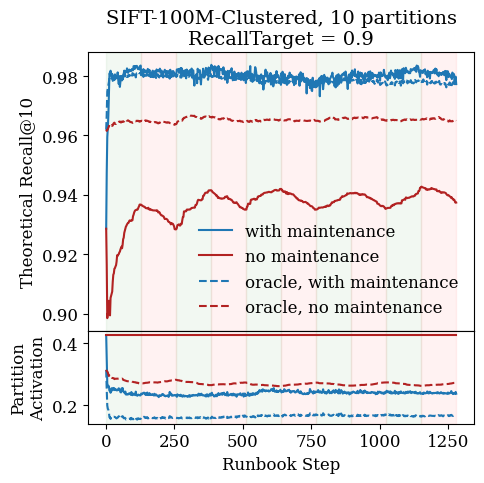

In [15]:
mode = "RecallTarget"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
# fig.set_size_inches(8, 5)

ax1.set_title(f"SIFT-100M-Clustered, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color = rebuilds_color
)

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)


ax1.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax1.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax1.legend(frameon=False)

ax2.plot(
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax2.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# ax3.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["step"], bigann_clustered_imbalance_t0,
#                  label=rebuilds_label, color=rebuilds_color
#                  )

# ax3.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["step"], bigann_clustered_imbalance_t100,
#                  label=no_rebuilds_label, color=no_rebuilds_color
#                  )

# ax3.set_xlabel("Runbook Step")
# ax3.set_ylabel("Partition\nImbalance")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)


fig.tight_layout()
fig.savefig("sift100clustered_recall_vs_step_recalltarget.pdf")

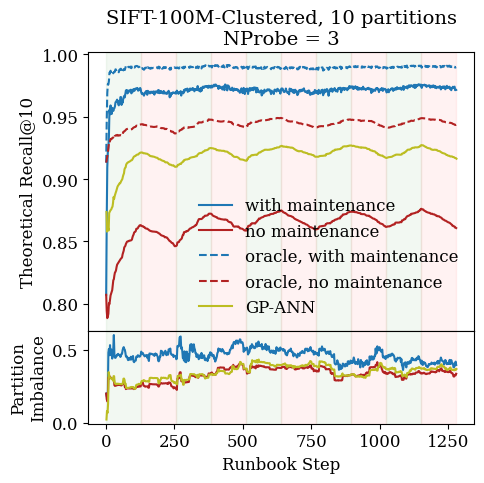

In [16]:
mode = "NProbe"
param = 3

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
# fig.set_size_inches(8, 5)

ax1.set_title(f"SIFT-100M-Clustered, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "NProbeOracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "NProbeOracle") &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--"
)

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "NProbeOracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "NProbeOracle") &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--"
)

ax1.plot(gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") 
                                & (gpann_bigann_clustered["nprobe"] == param)]["step"], 
                                gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") & 
                                (gpann_bigann_clustered["nprobe"] == param)]["theoretical_recall"], label="GP-ANN",
                                color="C8")

# ax1.plot(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="sometimes rebuilding (t=70%)"
# )

# ax1.scatter(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["recall"],
#     color="red", marker="x"
# )

# ax1.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["recall"],
#     label="oracle, always rebuilding", color="C0", ls="--")

# ax1.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["recall"],
#     label="oracle, never rebuilding", color="C1", ls="--")

# ax1.plot(bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="oracle, t=70%", color="C2", ls="--")

ax1.legend(frameon=False)

# ax2.plot(
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label=rebuilds_label, color=rebuilds_color
# )

# ax2.plot(
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax2.plot(gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") & (gpann_bigann_clustered["nprobe"] == param)]["step"], 
#          gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") & (gpann_bigann_clustered["nprobe"] == param)]["nprobe"]/10, label="GP-ANN", color="C8")

# ax2.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label="oracle, always rebuilding", color="C0", ls="--")

# ax2.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label="oracle, never rebuilding", color="C1", ls="--")

# ax2.set_xlabel("Runbook Step")
# ax2.set_ylabel("Partition\nActivation")

ax3.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"], bigann_clustered_imbalance_t0,
                 label=rebuilds_label, color=rebuilds_color
                 )

ax3.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"], bigann_clustered_imbalance_t100,
                 label=no_rebuilds_label, color=no_rebuilds_color
                 )

ax3.plot(gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") & (gpann_bigann_clustered["nprobe"] == param)]["step"], 
         gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") & (gpann_bigann_clustered["nprobe"] == param)]["gini"], label="GP-ANN", color="C8")

ax3.set_xlabel("Runbook Step")
ax3.set_ylabel("Partition\nImbalance")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)


fig.tight_layout()
fig.savefig("sift100clustered_recall_vs_step_nprobe.pdf")

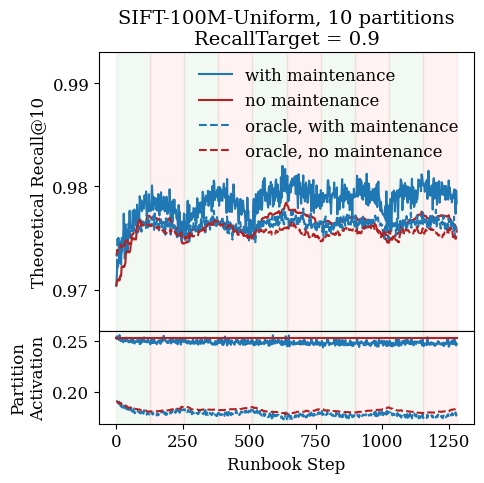

In [17]:
mode = "RecallTarget"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"SIFT-100M-Uniform, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

# ax1.plot(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="sometimes rebuilding (t=70%)"
# )

# ax1.scatter(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["recall"],
#     color="red", marker="x"
# )

ax1.plot(bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax1.plot(bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

# ax1.plot(bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="oracle, t=70%", color="C2", ls="--")

ax1.legend(frameon=False)

ax2.plot(
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax2.plot(bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)

# ax2.set_ylim(.13, .33)
ax1.set_yticks([.97, .98, .99])
ax1.set_yticks([.97, .98, .99])
ax1.set_ylim(.966, .993)

fig.tight_layout()
fig.savefig("sift100uniform_recall_vs_step_recalltarget.pdf")

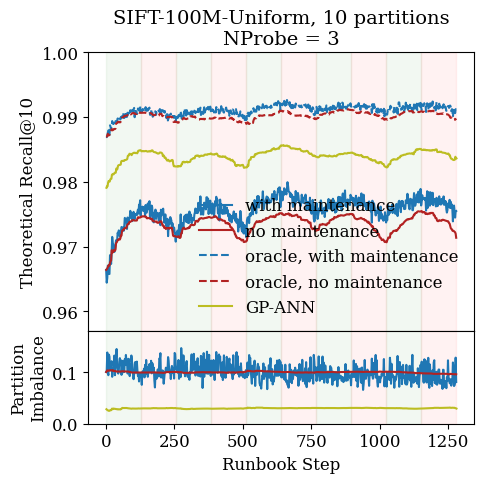

In [18]:
mode = "NProbe"
param = 3

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"SIFT-100M-Uniform, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

# ax1.plot(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="sometimes rebuilding (t=70%)"
# )

# ax1.scatter(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["recall"],
#     color="red", marker="x"
# )

# ax1.plot(bigann_random[(bigann_random["t"] == 0) &
#                   (bigann_random["mode"] == "Oracle") &
#                   (bigann_random["param"] == param)
#                  ]["step"],
#     bigann_random[(bigann_random["t"] == 0) &
#                   (bigann_random["mode"] == "Oracle") &
#                   (bigann_random["param"] == param)
#                  ]["recall"],
#     label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

# ax1.plot(bigann_random[(bigann_random["t"] == 100) &
#                   (bigann_random["mode"] == "Oracle") &
#                   (bigann_random["param"] == param)
#                  ]["step"],
#     bigann_random[(bigann_random["t"] == 100) &
#                   (bigann_random["mode"] == "Oracle") &
#                   (bigann_random["param"] == param)
#                  ]["recall"],
#     label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax1.plot(
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "NProbeOracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "NProbeOracle") &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--"
)

ax1.plot(
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "NProbeOracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "NProbeOracle") &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--"
)

ax1.plot(gpann_bigann_random[(gpann_bigann_random["operation"]=="SEARCH") 
                                & (gpann_bigann_random["nprobe"] == param)]["step"], 
                                gpann_bigann_random[(gpann_bigann_random["operation"]=="SEARCH") & 
                                (gpann_bigann_random["nprobe"] == param)]["theoretical_recall"], label="GP-ANN",
                                color="C8")

ax1.legend(frameon=False)

# ax2.plot(
#     bigann_random[(bigann_random["t"] == 0) &
#                   (bigann_random["mode"] == mode) &
#                   (bigann_random["param"] == param)
#                  ]["step"],
#     bigann_random[(bigann_random["t"] == 0) &
#                   (bigann_random["mode"] == mode) &
#                   (bigann_random["param"] == param)
#                  ]["activation"],
#     label=rebuilds_label, color=rebuilds_color
# )

# ax2.plot(
#     bigann_random[(bigann_random["t"] == 100) &
#                   (bigann_random["mode"] == mode) &
#                   (bigann_random["param"] == param)
#                  ]["step"],
#     bigann_random[(bigann_random["t"] == 100) &
#                   (bigann_random["mode"] == mode) &
#                   (bigann_random["param"] == param)
#                  ]["activation"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax2.plot(gpann_bigann_random[(gpann_bigann_random["operation"]=="SEARCH") & (gpann_bigann_random["nprobe"] == param)]["step"], 
#          gpann_bigann_random[(gpann_bigann_random["operation"]=="SEARCH") & (gpann_bigann_random["nprobe"] == param)]["nprobe"]/10, label="GP-ANN", color="C8")


# ax2.set_xlabel("Runbook Step")
# ax2.set_ylabel("Partition\nActivation")


ax3.plot(bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"], bigann_random_imbalance_t0,
                 label=rebuilds_label, color=rebuilds_color
                 )

ax3.plot(bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"], bigann_random_imbalance_t100,
                 label=no_rebuilds_label, color=no_rebuilds_color
                 )

ax3.plot(gpann_bigann_random[(gpann_bigann_random["operation"]=="SEARCH") 
                             & (gpann_bigann_random["nprobe"] == param)]["step"], 
         gpann_bigann_random[(gpann_bigann_random["operation"]=="SEARCH") 
                             & (gpann_bigann_random["nprobe"] == param)]["gini"], 
                             label="GP-ANN", color="C8")

ax3.set_xlabel("Runbook Step")
ax3.set_ylabel("Partition\nImbalance")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)

ax1.set_ylim(.957, 1.0)
ax3.set_ylim(0, .18)

fig.tight_layout()
fig.savefig("sift100uniform_recall_vs_step_nprobe.pdf")

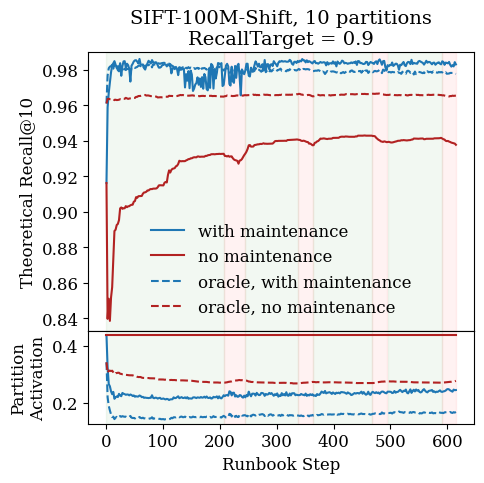

In [19]:
mode = "RecallTarget"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"SIFT-100M-Shift, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

# ax1.plot(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="sometimes rebuilding (t=70%)"
# )

# ax1.scatter(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["recall"],
#     color="red", marker="x"
# )

ax1.plot(bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax1.plot(bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

# ax1.plot(bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="oracle, t=70%", color="C2", ls="--")

ax1.legend(frameon=False)

ax2.plot(
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["activation"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["activation"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["activation"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax2.plot(bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == "Oracle") &
                  (bigann_shift["param"] == param)
                 ]["activation"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 208, color="green", alpha=0.05)
ax1.axvspan(208, 245, color="red", alpha=0.05)
ax1.axvspan(245, 338, color="green", alpha=0.05)
ax1.axvspan(338, 364, color="red", alpha=0.05)
ax1.axvspan(364, 468, color="green", alpha=0.05)
ax1.axvspan(468, 494, color="red", alpha=0.05)
ax1.axvspan(495, 590, color="green", alpha=0.05)
ax1.axvspan(590, 616, color="red", alpha=0.05)

ax2.axvspan(0, 208, color="green", alpha=0.05)
ax2.axvspan(208, 245, color="red", alpha=0.05)
ax2.axvspan(245, 338, color="green", alpha=0.05)
ax2.axvspan(338, 364, color="red", alpha=0.05)
ax2.axvspan(364, 468, color="green", alpha=0.05)
ax2.axvspan(468, 494, color="red", alpha=0.05)
ax2.axvspan(495, 590, color="green", alpha=0.05)
ax2.axvspan(590, 616, color="red", alpha=0.05)

# ax2.set_ylim(.13, .33)
ax1.set_ylim(.833, .99)

fig.tight_layout()
fig.savefig("sift100shift_recall_vs_step_recalltarget.pdf")

In [20]:
bigann_shift_imbalance_t0_steps = []
for step, group in bigann_shift_imbalance_df_t0.groupby("stepNum"):
    bigann_shift_imbalance_t0_steps.append(step)

bigann_shift_imbalance_t100_steps = []
for step, group in bigann_shift_imbalance_df_t100.groupby("stepNum"):
    bigann_shift_imbalance_t100_steps.append(step)

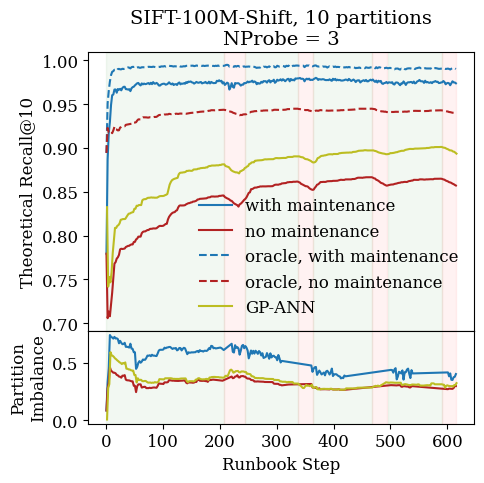

In [21]:
mode = "NProbe"
param = 3

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"SIFT-100M-Shift, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == mode) &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax1.plot(
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == "NProbeOracle") &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 0) &
                  (bigann_shift["mode"] == "NProbeOracle") &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--"
)

ax1.plot(
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == "NProbeOracle") &
                  (bigann_shift["param"] == param)
                 ]["step"],
    bigann_shift[(bigann_shift["t"] == 100) &
                  (bigann_shift["mode"] == "NProbeOracle") &
                  (bigann_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--"
)

ax1.plot(gpann_bigann_shift[(gpann_bigann_shift["operation"]=="SEARCH") 
                                & (gpann_bigann_shift["nprobe"] == param)]["step"], 
                                gpann_bigann_shift[(gpann_bigann_shift["operation"]=="SEARCH") & 
                                (gpann_bigann_shift["nprobe"] == param)]["theoretical_recall"], label="GP-ANN",
                                color="C8")

# ax1.plot(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="sometimes rebuilding (t=70%)"
# )

# ax1.scatter(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["recall"],
#     color="red", marker="x"
# )

# ax1.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["recall"],
#     label="oracle, always rebuilding", color="C0", ls="--")

# ax1.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["recall"],
#     label="oracle, never rebuilding", color="C1", ls="--")

# ax1.plot(bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="oracle, t=70%", color="C2", ls="--")

ax1.legend(frameon=False)

# ax2.plot(
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label=rebuilds_label, color=rebuilds_color
# )

# ax2.plot(
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == mode) &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax2.plot(gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") & (gpann_bigann_clustered["nprobe"] == param)]["step"], 
#          gpann_bigann_clustered[(gpann_bigann_clustered["operation"]=="SEARCH") & (gpann_bigann_clustered["nprobe"] == param)]["nprobe"]/10, label="GP-ANN", color="C8")

# ax2.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 0) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label="oracle, always rebuilding", color="C0", ls="--")

# ax2.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["step"],
#     bigann_clustered[(bigann_clustered["t"] == 100) &
#                   (bigann_clustered["mode"] == "Oracle") &
#                   (bigann_clustered["param"] == param)
#                  ]["activation"],
#     label="oracle, never rebuilding", color="C1", ls="--")

# ax2.set_xlabel("Runbook Step")
# ax2.set_ylabel("Partition\nActivation")

ax3.plot(bigann_shift_imbalance_t0_steps, bigann_shift_imbalance_t0,
                 label=rebuilds_label, color=rebuilds_color
                 )

ax3.plot(bigann_shift_imbalance_t100_steps, bigann_shift_imbalance_t100,
                 label=no_rebuilds_label, color=no_rebuilds_color
                 )

ax3.plot(gpann_bigann_shift[(gpann_bigann_shift["operation"]=="SEARCH") & (gpann_bigann_shift["nprobe"] == param)]["step"], 
         gpann_bigann_shift[(gpann_bigann_shift["operation"]=="SEARCH") & (gpann_bigann_shift["nprobe"] == param)]["gini"], label="GP-ANN", color="C8")

ax3.set_xlabel("Runbook Step")
ax3.set_ylabel("Partition\nImbalance")

# color in insert/delete phases
ax1.axvspan(0, 208, color="green", alpha=0.05)
ax1.axvspan(208, 245, color="red", alpha=0.05)
ax1.axvspan(245, 338, color="green", alpha=0.05)
ax1.axvspan(338, 364, color="red", alpha=0.05)
ax1.axvspan(364, 468, color="green", alpha=0.05)
ax1.axvspan(468, 494, color="red", alpha=0.05)
ax1.axvspan(495, 590, color="green", alpha=0.05)
ax1.axvspan(590, 616, color="red", alpha=0.05)

ax3.axvspan(0, 208, color="green", alpha=0.05)
ax3.axvspan(208, 245, color="red", alpha=0.05)
ax3.axvspan(245, 338, color="green", alpha=0.05)
ax3.axvspan(338, 364, color="red", alpha=0.05)
ax3.axvspan(364, 468, color="green", alpha=0.05)
ax3.axvspan(468, 494, color="red", alpha=0.05)
ax3.axvspan(495, 590, color="green", alpha=0.05)
ax3.axvspan(590, 616, color="red", alpha=0.05)


fig.tight_layout()
fig.savefig("sift100shift_recall_vs_step_nprobe.pdf")

# MSTuring ----------------

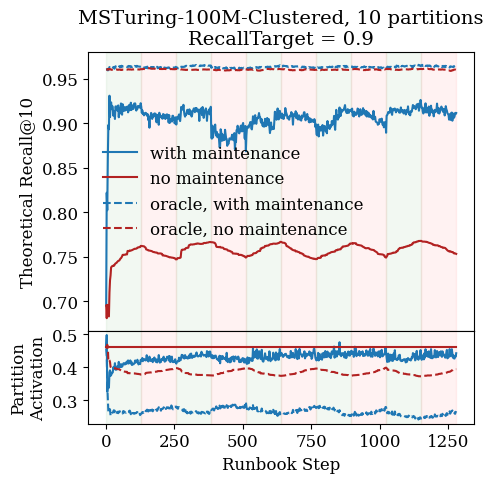

In [22]:
mode = "RecallTarget"
param = .9
gpann_param = 5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"MSTuring-100M-Clustered, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

# ax1.plot(
#     msturing_clustered_distrib_t100[
#                   (msturing_clustered_distrib_t100["mode"] == mode) &
#                   (msturing_clustered_distrib_t100["param"] == param)
#                  ]["step"],
#     msturing_clustered_distrib_t100[
#                   (msturing_clustered_distrib_t100["mode"] == mode) &
#                   (msturing_clustered_distrib_t100["param"] == param)
#                  ]["theoretical_recall@10"],
#     label="never rebuilding, distrib"
# )

# ax1.plot(
#     msturing_clustered_distrib_t100[
#                   (msturing_clustered_distrib_t100["mode"] == mode) &
#                   (msturing_clustered_distrib_t100["param"] == param)
#                  ]["step"],
#     msturing_clustered_distrib_t100[
#                   (msturing_clustered_distrib_t100["mode"] == mode) &
#                   (msturing_clustered_distrib_t100["param"] == param)
#                  ]["recall@10"],
#     label="never rebuilding, distrib real", color="C2", ls=":"
# )

# ax1.plot(
#     msturing_clustered_distrib_t60[
#                   (msturing_clustered_distrib_t60["mode"] == mode) &
#                   (msturing_clustered_distrib_t60["param"] == param)
#                  ]["step"],
#     msturing_clustered_distrib_t60[
#                   (msturing_clustered_distrib_t60["mode"] == mode) &
#                   (msturing_clustered_distrib_t60["param"] == param)
#                  ]["theoretical_recall@10"],
#     label="t=60 rebuilding, distrib", color="C3"
# )

# ax1.plot(
#     msturing_clustered_distrib_t60[
#                   (msturing_clustered_distrib_t60["mode"] == mode) &
#                   (msturing_clustered_distrib_t60["param"] == param)
#                  ]["step"],
#     msturing_clustered_distrib_t60[
#                   (msturing_clustered_distrib_t60["mode"] == mode) &
#                   (msturing_clustered_distrib_t60["param"] == param)
#                  ]["recall@10"],
#     label="t=60 rebuilding, distrib real", color="C3", ls=":"
# )

ax1.plot(msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax1.plot(msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax1.legend(frameon=False)

ax2.plot(
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax2.plot(msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)


fig.tight_layout()
fig.savefig("msturing100clustered_recall_vs_step_recalltarget.pdf")

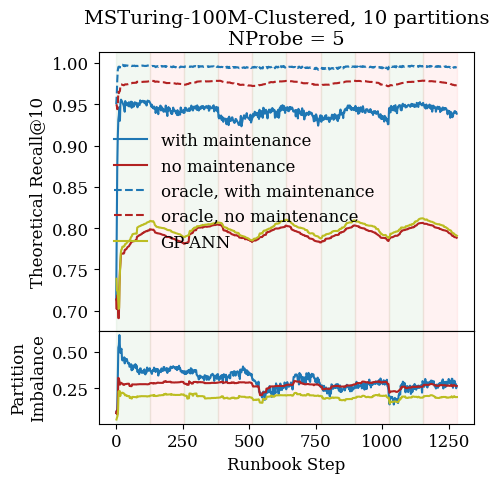

In [23]:
mode = "NProbe"
param = 5

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"MSTuring-100M-Clustered, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "NProbeOracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "NProbeOracle") &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--"
)

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "NProbeOracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "NProbeOracle") &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--"
)

ax1.plot(gpann_msturing_clustered[(gpann_msturing_clustered["operation"] == "SEARCH") &
                  (gpann_msturing_clustered["nprobe"] == param)
                 ]["step"],
    gpann_msturing_clustered[(gpann_msturing_clustered["operation"] == "SEARCH") &
                  (gpann_msturing_clustered["nprobe"] == param)
                 ]["theoretical_recall"],
    label=f"GP-ANN", color="C8")

ax1.legend(frameon=False)

# ax2.plot(
#     msturing_clustered[(msturing_clustered["t"] == 0) &
#                   (msturing_clustered["mode"] == mode) &
#                   (msturing_clustered["param"] == param)
#                  ]["step"],
#     msturing_clustered[(msturing_clustered["t"] == 0) &
#                   (msturing_clustered["mode"] == mode) &
#                   (msturing_clustered["param"] == param)
#                  ]["activation"],
#     label=rebuilds_label, color=rebuilds_color
# )

# ax2.plot(
#     msturing_clustered[(msturing_clustered["t"] == 100) &
#                   (msturing_clustered["mode"] == mode) &
#                   (msturing_clustered["param"] == param)
#                  ]["step"],
#     msturing_clustered[(msturing_clustered["t"] == 100) &
#                   (msturing_clustered["mode"] == mode) &
#                   (msturing_clustered["param"] == param)
#                  ]["activation"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax2.plot(gpann_msturing_clustered[(gpann_msturing_clustered["operation"] == "SEARCH") &
#                   (gpann_msturing_clustered["nprobe"] == param)
#                  ]["step"],
#     gpann_msturing_clustered[(gpann_msturing_clustered["operation"] == "SEARCH") &
#                   (gpann_msturing_clustered["nprobe"] == param)
#                  ]["nprobe"]/10,
#     label=f"GP-ANN", color="C8")

# ax2.set_xlabel("Runbook Step")
# ax2.set_ylabel("Partition\nActivation")

ax3.plot(msturing_clustered[(msturing_clustered["t"] == 100) & 
                   (msturing_clustered["mode"] == mode) &
                   (msturing_clustered["param"] == param)]["step"], msturing_clustered_imbalance_t0,
                 label=rebuilds_label, color=rebuilds_color
                 )

ax3.plot(msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"], msturing_clustered_imbalance_t100,
                 label=no_rebuilds_label, color=no_rebuilds_color
                 )

ax3.plot(gpann_msturing_clustered[(gpann_msturing_clustered["operation"]=="SEARCH") 
                             & (gpann_msturing_clustered["nprobe"] == param)]["step"], 
         gpann_msturing_clustered[(gpann_msturing_clustered["operation"]=="SEARCH") 
                             & (gpann_msturing_clustered["nprobe"] == param)]["gini"], 
                             label="GP-ANN", color="C8")

ax3.set_xlabel("Runbook Step")
ax3.set_ylabel("Partition\nImbalance")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)


fig.tight_layout()
fig.savefig("msturing100clustered_recall_vs_step_nprobe.pdf")

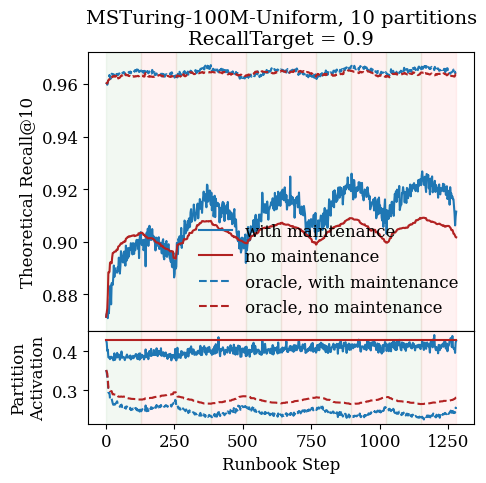

In [24]:
mode = "RecallTarget"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"MSTuring-100M-Uniform, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax1.plot(msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax1.plot(msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax1.legend(frameon=False)

ax2.plot(
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax2.plot(msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)

fig.tight_layout()
fig.savefig("msturing100uniform_recall_vs_step_recalltarget.pdf")

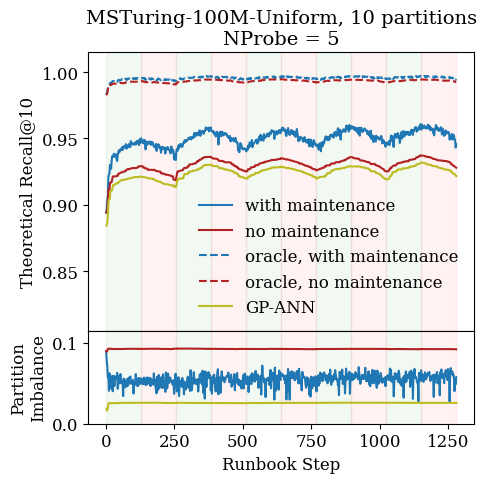

In [25]:
mode = "NProbe"
param = 5

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"MSTuring-100M-Uniform, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax1.plot(
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "NProbeOracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "NProbeOracle") &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--"
)

ax1.plot(
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "NProbeOracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "NProbeOracle") &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--"
)


ax1.plot(gpann_msturing_random[(gpann_msturing_random["operation"] == "SEARCH") &
                  (gpann_msturing_random["nprobe"] == param)
                 ]["step"],
    gpann_msturing_random[(gpann_msturing_random["operation"] == "SEARCH") &
                  (gpann_msturing_random["nprobe"] == param)
                 ]["theoretical_recall"],
    label=f"GP-ANN", color="C8")

ax1.legend(frameon=False)

# ax2.plot(
#     msturing_random[(msturing_random["t"] == 0) &
#                   (msturing_random["mode"] == mode) &
#                   (msturing_random["param"] == param)
#                  ]["step"],
#     msturing_random[(msturing_random["t"] == 0) &
#                   (msturing_random["mode"] == mode) &
#                   (msturing_random["param"] == param)
#                  ]["activation"],
#     label=rebuilds_label, color=rebuilds_color
# )

# ax2.plot(
#     msturing_random[(msturing_random["t"] == 100) &
#                   (msturing_random["mode"] == mode) &
#                   (msturing_random["param"] == param)
#                  ]["step"],
#     msturing_random[(msturing_random["t"] == 100) &
#                   (msturing_random["mode"] == mode) &
#                   (msturing_random["param"] == param)
#                  ]["activation"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax2.plot(gpann_msturing_random[(gpann_msturing_random["operation"] == "SEARCH") &
#                   (gpann_msturing_random["nprobe"] == param)
#                  ]["step"],
#     gpann_msturing_random[(gpann_msturing_random["operation"] == "SEARCH") &
#                   (gpann_msturing_random["nprobe"] == param)
#                  ]["nprobe"]/10,
#     label=f"GP-ANN", color="C8")

# ax2.set_xlabel("Runbook Step")
# ax2.set_ylabel("Partition\nActivation")

ax3.plot(msturing_random[(msturing_random["t"] == 0) & 
                   (msturing_random["mode"] == mode) &
                   (msturing_random["param"] == param)]["step"], msturing_random_imbalance_t0,
                 label=rebuilds_label, color=rebuilds_color
                 )

ax3.plot(msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"], msturing_random_imbalance_t100,
                 label=no_rebuilds_label, color=no_rebuilds_color
                 )

ax3.plot(gpann_msturing_random[(gpann_msturing_random["operation"]=="SEARCH") 
                             & (gpann_msturing_random["nprobe"] == param)]["step"], 
         gpann_msturing_random[(gpann_msturing_random["operation"]=="SEARCH") 
                             & (gpann_msturing_random["nprobe"] == param)]["gini"], 
                             label="GP-ANN", color="C8")

ax3.set_xlabel("Runbook Step")
ax3.set_ylabel("Partition\nImbalance")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)

ax3.set_ylim(0, .115)
ax1.set_ylim(.805, 1.015)

fig.tight_layout()
fig.savefig("msturing100uniform_recall_vs_step_nprobe.pdf")

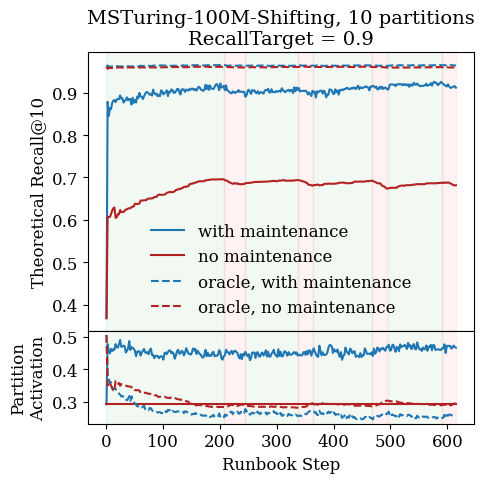

In [26]:
mode = "RecallTarget"
param = .9
gpann_param = 5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5,5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title(f"MSTuring-100M-Shifting, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax1.plot(msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax1.plot(msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")

# ax1.plot(
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 100) &
#                   (msturing_shift_weighted["mode"] == "Oracle") &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["step"],
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 100) &
#                   (msturing_shift_weighted["mode"] == "Oracle") &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["recall"],
#     label="weighted, no maintenance", color="C9"
# )

# ax1.plot(
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 0) &
#                   (msturing_shift_weighted["mode"] == "Oracle") &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["step"],
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 0) &
#                   (msturing_shift_weighted["mode"] == "Oracle") &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["recall"],
#     label="weighted, with maintenance", color="C7"
# )

ax1.legend(frameon=False)

ax2.plot(
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--")

ax2.plot(msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--")


# ax2.plot(
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 100) &
#                   (msturing_shift_weighted["mode"] == "Oracle") &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["step"],
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 100) &
#                   (msturing_shift_weighted["mode"] == "Oracle") &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["activation"],
#     label="weighted, no maintenance", color="C9"
# )

# ax2.plot(
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 0) &
#                   (msturing_shift_weighted["mode"] == mode) &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["step"],
#     msturing_shift_weighted[(msturing_shift_weighted["t"] == 0) &
#                   (msturing_shift_weighted["mode"] == mode) &
#                   (msturing_shift_weighted["param"] == param)
#                  ]["activation"],
#     label="weighted, with maintenance", color="C7"
# )

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases for shifting dataset
# shift runbook phases:
# step 0-208: insert
# step 208-245: delete
# step 235-338: insert
# step 338-364: delete
# step 365-468: insert
# step 468-494: delete
# step 495-590: insert
# step 591-616: delete

ax1.axvspan(0, 208, color="green", alpha=0.05)
ax1.axvspan(208, 245, color="red", alpha=0.05)
ax1.axvspan(245, 338, color="green", alpha=0.05)
ax1.axvspan(338, 364, color="red", alpha=0.05)
ax1.axvspan(364, 468, color="green", alpha=0.05)
ax1.axvspan(468, 494, color="red", alpha=0.05)
ax1.axvspan(495, 590, color="green", alpha=0.05)
ax1.axvspan(590, 616, color="red", alpha=0.05)

ax2.axvspan(0, 208, color="green", alpha=0.05)
ax2.axvspan(208, 245, color="red", alpha=0.05)
ax2.axvspan(245, 338, color="green", alpha=0.05)
ax2.axvspan(338, 364, color="red", alpha=0.05)
ax2.axvspan(364, 468, color="green", alpha=0.05)
ax2.axvspan(468, 494, color="red", alpha=0.05)
ax2.axvspan(495, 590, color="green", alpha=0.05)
ax2.axvspan(590, 616, color="red", alpha=0.05)


fig.tight_layout()
fig.savefig("msturing100shift_recall_vs_step_recalltarget.pdf")

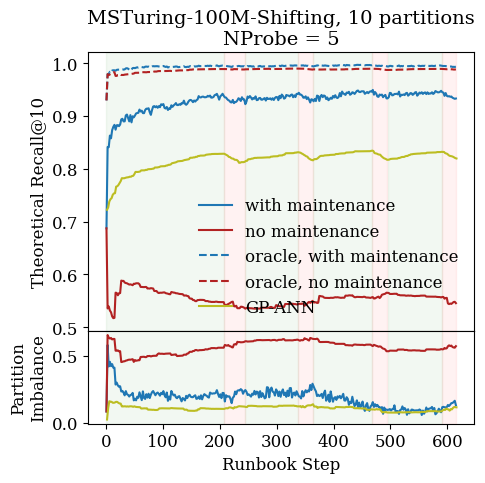

In [27]:
mode = "NProbe"
param = 5

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(5,5), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
# fig.set_size_inches(8, 5)

ax1.set_title(f"MSTuring-100M-Shifting, 10 partitions\n{mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=rebuilds_label, color=rebuilds_color
)

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "NProbeOracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "NProbeOracle") &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color=rebuilds_color, ls="--"
)

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "NProbeOracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "NProbeOracle") &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label=f"oracle, {no_rebuilds_label}", color=no_rebuilds_color, ls="--"
)


ax1.plot(gpann_msturing_shift[(gpann_msturing_shift["operation"] == "SEARCH") &
                    (gpann_msturing_shift["nprobe"] == param)]["step"],
    gpann_msturing_shift[(gpann_msturing_shift["operation"] == "SEARCH") &
                    (gpann_msturing_shift["nprobe"] == param)]["theoretical_recall"],
    label=f"GP-ANN", color="C8")
    

ax1.legend(frameon=False)

# ax2.plot(
#     msturing_shift[(msturing_shift["t"] == 0) &
#                   (msturing_shift["mode"] == mode) &
#                   (msturing_shift["param"] == param)
#                  ]["step"],
#     msturing_shift[(msturing_shift["t"] == 0) &
#                   (msturing_shift["mode"] == mode) &
#                   (msturing_shift["param"] == param)
#                  ]["activation"],
#     label=rebuilds_label, color=rebuilds_color
# )

# ax2.plot(
#     msturing_shift[(msturing_shift["t"] == 100) &
#                   (msturing_shift["mode"] == mode) &
#                   (msturing_shift["param"] == param)
#                  ]["step"],
#     msturing_shift[(msturing_shift["t"] == 100) &
#                   (msturing_shift["mode"] == mode) &
#                   (msturing_shift["param"] == param)
#                  ]["activation"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax2.plot(gpann_msturing_shift[(gpann_msturing_shift["operation"] == "SEARCH") &
#                     (gpann_msturing_shift["nprobe"] == param)]["step"],
#     gpann_msturing_shift[(gpann_msturing_shift["operation"] == "SEARCH") &
#                     (gpann_msturing_shift["nprobe"] == param)]["nprobe"]/10,
#     label=f"GP-ANN", color="C8")

# ax2.set_xlabel("Runbook Step")
# ax2.set_ylabel("Partition\nActivation")

ax3.plot(msturing_shift[(msturing_shift["t"] == 0) & 
                   (msturing_shift["mode"] == mode) &
                   (msturing_shift["param"] == param)]["step"], msturing_shift_imbalance_t0,
                 label=rebuilds_label, color=rebuilds_color
                 )

ax3.plot(msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"], msturing_shift_imbalance_t100,
                 label=no_rebuilds_label, color=no_rebuilds_color
                 )

ax3.plot(gpann_msturing_shift[(gpann_msturing_shift["operation"]=="SEARCH") 
                             & (gpann_msturing_shift["nprobe"] == param)]["step"], 
         gpann_msturing_shift[(gpann_msturing_shift["operation"]=="SEARCH") 
                             & (gpann_msturing_shift["nprobe"] == param)]["gini"], 
                             label="GP-ANN", color="C8")

ax3.set_xlabel("Runbook Step")
ax3.set_ylabel("Partition\nImbalance")

ax1.axvspan(0, 208, color="green", alpha=0.05)
ax1.axvspan(208, 245, color="red", alpha=0.05)
ax1.axvspan(245, 338, color="green", alpha=0.05)
ax1.axvspan(338, 364, color="red", alpha=0.05)
ax1.axvspan(364, 468, color="green", alpha=0.05)
ax1.axvspan(468, 494, color="red", alpha=0.05)
ax1.axvspan(495, 590, color="green", alpha=0.05)
ax1.axvspan(590, 616, color="red", alpha=0.05)

ax3.axvspan(0, 208, color="green", alpha=0.05)
ax3.axvspan(208, 245, color="red", alpha=0.05)
ax3.axvspan(245, 338, color="green", alpha=0.05)
ax3.axvspan(338, 364, color="red", alpha=0.05)
ax3.axvspan(364, 468, color="green", alpha=0.05)
ax3.axvspan(468, 494, color="red", alpha=0.05)
ax3.axvspan(495, 590, color="green", alpha=0.05)
ax3.axvspan(590, 616, color="red", alpha=0.05)

fig.tight_layout()
fig.savefig("msturing100shift_recall_vs_step_nprobe.pdf")